## MARBL diagnostics, compare timeseries of global metrics between multiple cases (only 2-d variables)


In [1]:
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
import os
from glob import glob
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
import cftime
import pandas as pd
import matplotlib.gridspec as gridspec
from xgcm import Grid
xr.set_options(keep_attrs=True);

### Cases to be compared with major changes

#### All cases with alpha09a tag 
(/glade/work/mlevy/codes/CESM/cesm3_0_alpha09a_MARBL_t233)

• 017: new iron scavenging 

• 018: 017 + dust_ratio 9.903 --> 9.9

• 019: 018 + FE_TO_BC_RATIO 1.33 --> 1.20

• 020: 017 + Keith M.'s suggested grazing POC routing changes

• 021: 017 + dust_ratio 9.903 --> 7.55

• 022: 017 + CaCO3 diss zoo guts --> 0.92

• 024: 017 + 2x Fe sed flux south of 60°S

• 025: 017 + new Fe sed flux (v3_2y)

### Come up with short names for each case

In [2]:
short_names = ['017 (new Fe scav)',
               '018 (017 + dust ratio=9.9)',
               '019 (018 + Fe:BC=1.2)',
               '020 (017 + grazePOC mods)',
               '021 (017 + dust ratio=7.55)',
               '022 (017 + CaCO3diss zoo guts=0.92)',
               '024 (017 + 2x Fe sed flux SO)',
               '025 (017 + new Fed sed flux v3_2y)']

### Define number of years and number of cases

In [3]:
num_cases = 8
num_years = 10

### Define cases

In [4]:
sandbox = 'g.e30_a09.GW1850MARBL_JRA.TL319_t233_wgx3_hycom1_N75'

case_nums = ['017','018','019','020','021','022','024','025']

user = 'kristenk'

### Define the year range

In [5]:
start_yr = 1
endyr = start_yr + num_years 

### 2-D variable list

In [6]:
variables2d = ['photoC_TOT_zint','photoC_sp_zint','photoC_diat_zint',
               'photoC_diaz_zint','photoC_cocco_zint','CaCO3_PROD_zint',
               'POC_FLUX_100m','x_graze_microzoo_zint',
               'x_graze_mesozoo_zint','IFRAC','FG_CO2','diat_Fe_lim_surf'] 

coords = {'x':'yh','y':'xh'}


keepthese=['z_l','z_i','time_bounds','time','average_T1', 'average_T2','average_DT'] + variables2d + list(coords.values())

### Get dask going

In [7]:
def get_ClusterClient():
    import dask
    from dask_jobqueue import PBSCluster
    from dask.distributed import Client
    cluster = PBSCluster(
        cores=2,
        memory='25 GB',
        processes=1,
        queue='casper',
        resource_spec='select=1:ncpus=1:mem=25GB',
        project='NCGD0011',
        walltime='03:00:00',
        interface='ext',)

    dask.config.set({
        'distributed.dashboard.link':
        'https://jupyterhub.hpc.ucar.edu/stable/user/{USER}/proxy/{port}/status'
    })
    client = Client(cluster)
    return cluster, client

In [8]:
cluster, client = get_ClusterClient()
cluster.scale(12) 
client

Client Scheduler: tcp://128.117.208.174:35001 Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/kristenk/proxy/41681/status,Cluster Workers: 0 Cores: 0 Memory: 0 B


### Read in all the data

In [9]:
cases_dict = {}

for case_num in case_nums:
    case = sandbox + '.' + case_num
    print(case)
    files = []
    for year in range(start_yr,endyr):
        yr4="{:04d}".format(year)
        print('doing simulation year', year, '!')
        for month in range(1, 13):
            mo2="{:02d}".format(month)
            files.extend(sorted(glob(f'/glade/derecho/scratch/{user}/archive/{case}/ocn/hist/{case}.mom6.h.bgc.native.{yr4}-{mo2}.nc')))
    ds_tmp = xr.open_mfdataset(files,decode_times=True,decode_coords=False, concat_dim='time')
    ### drop unnecessary variables
    ds_tmp = ds_tmp.drop([v for v in ds_tmp.variables if v not in keepthese])
    ### resample to annual means
    cases_dict[case_num] = ds_tmp.resample({'time':'A'}).mean(dim='time', keep_attrs=True).compute()

g.e30_a09.GW1850MARBL_JRA.TL319_t233_wgx3_hycom1_N75.017
doing simulation year 1 !
doing simulation year 2 !
doing simulation year 3 !
doing simulation year 4 !
doing simulation year 5 !
doing simulation year 6 !
doing simulation year 7 !
doing simulation year 8 !
doing simulation year 9 !
doing simulation year 10 !
g.e30_a09.GW1850MARBL_JRA.TL319_t233_wgx3_hycom1_N75.018
doing simulation year 1 !
doing simulation year 2 !
doing simulation year 3 !
doing simulation year 4 !
doing simulation year 5 !
doing simulation year 6 !
doing simulation year 7 !
doing simulation year 8 !
doing simulation year 9 !
doing simulation year 10 !
g.e30_a09.GW1850MARBL_JRA.TL319_t233_wgx3_hycom1_N75.019
doing simulation year 1 !
doing simulation year 2 !
doing simulation year 3 !
doing simulation year 4 !
doing simulation year 5 !
doing simulation year 6 !
doing simulation year 7 !
doing simulation year 8 !
doing simulation year 9 !
doing simulation year 10 !
g.e30_a09.GW1850MARBL_JRA.TL319_t233_wgx3_hyco

In [10]:
cases_dict.keys()

dict_keys(['017', '018', '019', '020', '021', '022', '024', '025'])

## Get the grid data for MOM6

In [11]:
ds_grid = xr.open_dataset(f'/glade/work/kristenk/cesm_work/mom6_static_files/g.e23b16.TL319_t232.GIAFMARBL.001.mom6.h.static.nc')

In [12]:
lons = ds_grid.geolon
lats = ds_grid.geolat
area = ds_grid.areacello #m2

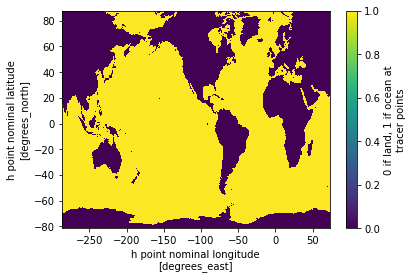

In [13]:
ds_grid.wet.plot()

### Compute global BGC metrics 

In [14]:
mmols_to_PgCyr = 1e-3 * 12. * 1e-15 * 365. * 86400.

variables = [f'photoC_{phyto}_zint' for phyto in ['diat', 'sp', 'diaz', 'cocco', 'TOT']]
variables = variables + ['CaCO3_PROD_zint','POC_FLUX_100m','FG_CO2']
variables = variables + [f'x_graze_{zoo}_zint' for zoo in ['microzoo', 'mesozoo']]


glb_ds_dict = {}

for case_num in case_nums:
    
    case = sandbox + '.' + case_num

    ds_glb = xr.Dataset()

    ds = cases_dict[case_num]
    
    for v in variables:
        ds_glb[v] = ((ds[v] * area).sum(dim=('xh', 'yh'))).compute() #mmol/m
        ds_glb[v].attrs = ds[v].attrs
    
        ds_glb[v] = ds_glb[v] * mmols_to_PgCyr        
        ds_glb[v].attrs['units'] = 'Pg C yr$^{-1}$'
    
    
    ######### diatom and zooplankton percents of total NPP
    ds_glb['diatNPPpercent'] = ds_glb.photoC_diat_zint / ds_glb.photoC_TOT_zint * 100.
    ds_glb['diatNPPpercent'].attrs['units'] = '%'
    
    ds_glb['zooprodNPPpercent'] = (ds_glb['x_graze_mesozoo_zint'] + ds_glb['x_graze_microzoo_zint'])/ds_glb['photoC_TOT_zint'] * 100.
    ds_glb['zooprodNPPpercent'].attrs['units'] = '%'
    
    ds_glb = ds_glb.compute()

    glb_ds_dict[case_num] = ds_glb

In [15]:
glb_ds_dict.keys()

dict_keys(['017', '018', '019', '020', '021', '022', '024', '025'])

In [16]:
glb_ds_dict['017'].photoC_cocco_zint

<xarray.DataArray 'photoC_cocco_zint' (time: 10)>
array([5.302374 , 6.2768536, 6.206853 , 6.1495657, 6.102193 , 6.115114 ,
       6.053612 , 6.090196 , 6.0092573, 6.007446 ], dtype=float32)
Coordinates:
  * time     (time) object 0001-12-31 00:00:00 ... 0010-12-31 00:00:00
Attributes:
    units:          Pg C yr$^{-1}$
    long_name:      Coccolithophores C Fixation Vertical Integral
    cell_methods:   area:mean yh:mean xh:mean time: mean
    cell_measures:  area: areacello
    time_avg_info:  average_T1,average_T2,average_DT

### Make some timeseries plots for global BGC metrics

In [17]:
years = np.arange(1,len(ds_glb.time)+1,1)

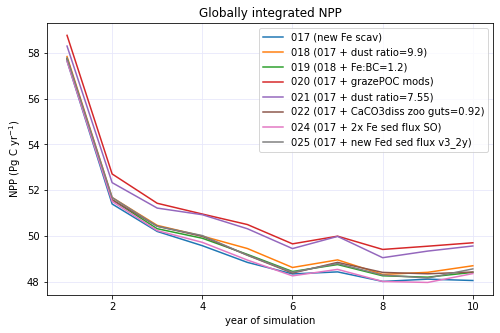

In [18]:
fig = plt.figure(figsize=(8,5))

ax = fig.add_subplot(1,1,1)
ax.set_title('Globally integrated NPP')

i = 0

for case_num in case_nums:

    ax.plot(years,glb_ds_dict[case_num]['photoC_TOT_zint'],label=short_names[i])
    i = i + 1


ax.xaxis.grid(True, which='major',color='lavender')
ax.yaxis.grid(False, which='major',color='lavender');

ax.legend()
ax.set(ylabel='NPP (Pg C yr$^{-1}$)',xlabel='year of simulation');

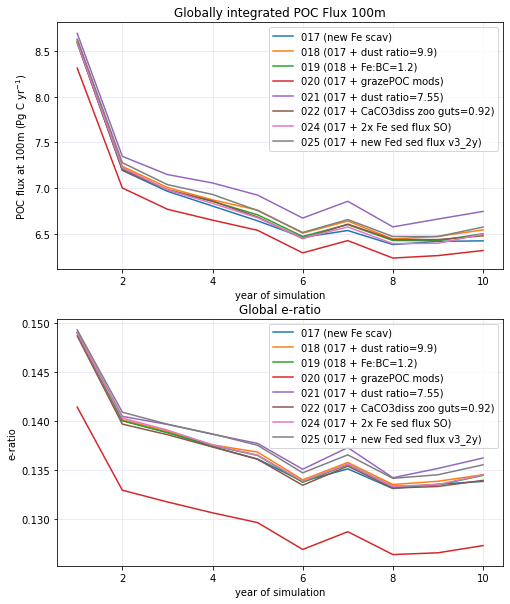

In [19]:
fig = plt.figure(figsize=(8,10))

####################
ax = fig.add_subplot(2,1,1)
ax.set_title('Globally integrated POC Flux 100m')

i = 0

for case_num in case_nums:

    ax.plot(years,glb_ds_dict[case_num]['POC_FLUX_100m'],label=short_names[i])
    i = i + 1

ax.xaxis.grid(True, which='major',color='lavender')
ax.yaxis.grid(False, which='major',color='lavender');

ax.legend()
ax.set(ylabel='POC flux at 100m (Pg C yr$^{-1}$)',xlabel='year of simulation');

######################
ax = fig.add_subplot(2,1,2)
ax.set_title('Global e-ratio')

i = 0

for case_num in case_nums:

    ax.plot(years,glb_ds_dict[case_num]['POC_FLUX_100m']/glb_ds_dict[case_num]['photoC_TOT_zint'],label=short_names[i])
    i = i + 1

ax.xaxis.grid(True, which='major',color='lavender')
ax.yaxis.grid(False, which='major',color='lavender');

ax.legend()
ax.set(ylabel='e-ratio',xlabel='year of simulation');

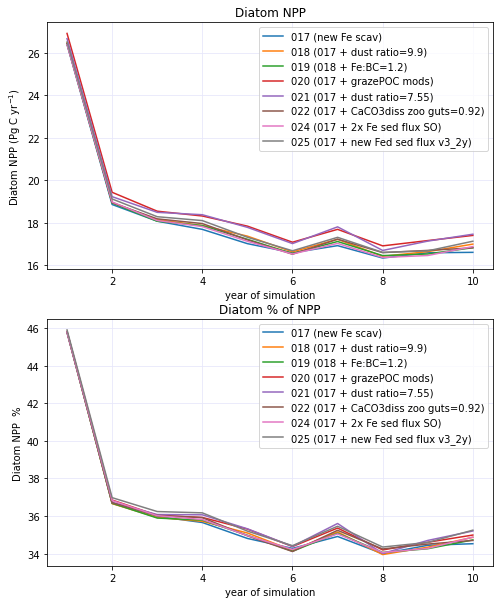

In [20]:
fig = plt.figure(figsize=(8,10))

#################
ax = fig.add_subplot(2,1,1)
ax.set_title('Diatom NPP')

i = 0

for case_num in case_nums:

    ax.plot(years,glb_ds_dict[case_num]['photoC_diat_zint'],label=short_names[i])
    i = i + 1

ax.xaxis.grid(True, which='major',color='lavender')
ax.yaxis.grid(False, which='major',color='lavender');

ax.legend()

ax.set(ylabel='Diatom NPP (Pg C yr$^{-1}$)',xlabel='year of simulation');

##################
ax = fig.add_subplot(2,1,2)
ax.set_title('Diatom % of NPP')

i = 0

for case_num in case_nums:

    ax.plot(years,glb_ds_dict[case_num]['diatNPPpercent'],label=short_names[i])
    i = i + 1

ax.xaxis.grid(True, which='major',color='lavender')
ax.yaxis.grid(False, which='major',color='lavender');

ax.legend()

ax.set(ylabel='Diatom NPP  %',xlabel='year of simulation');

### Difference maps (end - start)

In [21]:
diff_map_dict = {}

for case_num in case_nums:

    print(case_num)

    ds = cases_dict[case_num]

    ds_diff = ds.isel(time=num_years-1) - ds.isel(time=0)

    diff_map_dict[case_num] = ds_diff

017
018
019
020
021
022
024
025


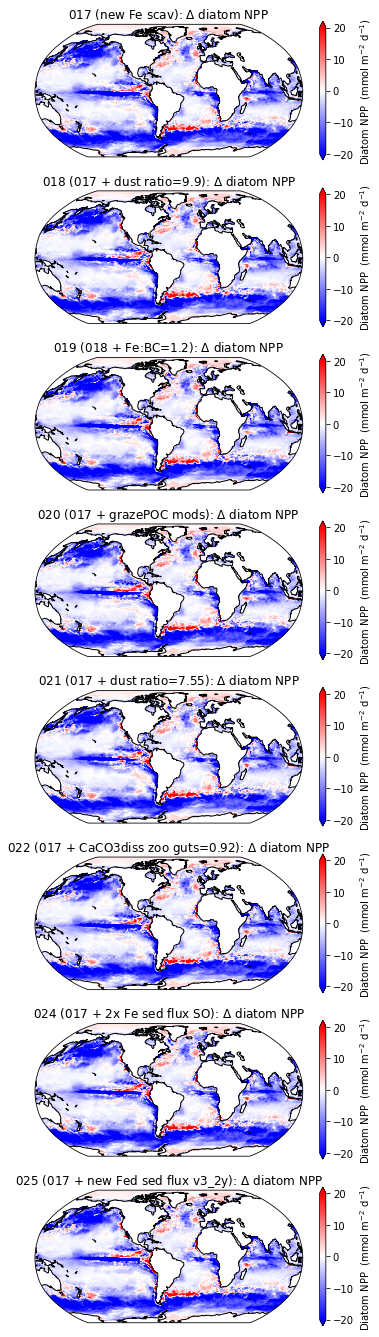

In [22]:
fig = plt.figure(figsize=(6,3*num_cases))
convert =  86400.

i = 0
for case_num in case_nums:

    ax = fig.add_subplot(num_cases,1,i+1, projection=ccrs.Robinson(central_longitude=305.0))
    ax.set_title(short_names[i] + ': ${\Delta}$ diatom NPP', fontsize=12)
    
    pc=ax.pcolormesh(lons, lats, diff_map_dict[case_num]['photoC_diat_zint'] * convert, cmap='bwr',
                     vmin=-20,vmax=20,
                     transform=ccrs.PlateCarree())
    
    ax.coastlines('110m',linewidth=1)
    cbar1 = fig.colorbar(pc, ax=ax,extend='both',label='Diatom NPP  (mmol m$^{-2}$ d$^{-1}$)')

    i = i + 1

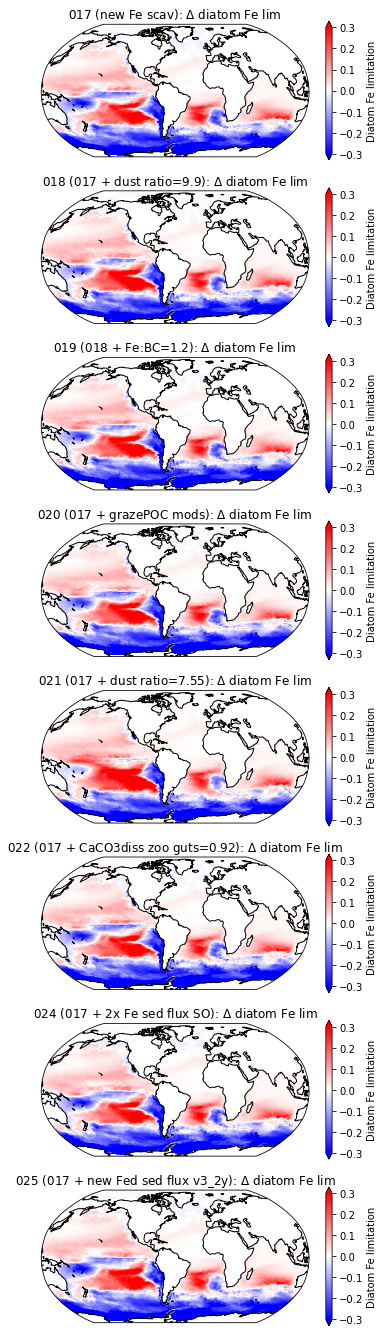

In [23]:
fig = plt.figure(figsize=(6,3*num_cases))

i = 0
for case_num in case_nums:

    ax = fig.add_subplot(num_cases,1,i+1, projection=ccrs.Robinson(central_longitude=305.0))
    ax.set_title(short_names[i] + ': ${\Delta}$ diatom Fe lim', fontsize=12)
    
    pc=ax.pcolormesh(lons, lats, diff_map_dict[case_num]['diat_Fe_lim_surf'], cmap='bwr',
                     vmin=-0.3,vmax=0.3,
                     transform=ccrs.PlateCarree())
    
    ax.coastlines('110m',linewidth=1)
    cbar1 = fig.colorbar(pc, ax=ax,extend='both',label='Diatom Fe limitation')

    i = i + 1

### diatom productivity in last 2 years: 017 vs. other runs

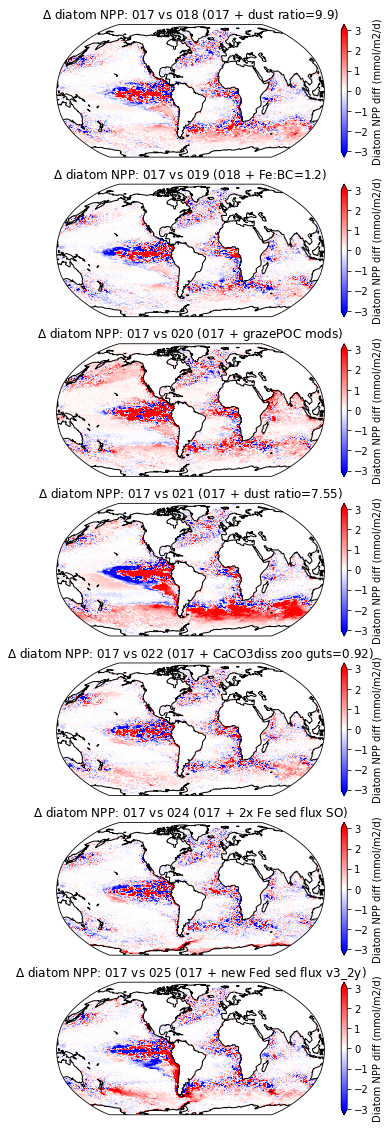

In [25]:
fig = plt.figure(figsize=(6,3*num_cases-1))

i = 1
for case_num in case_nums[1:8]:

    ax = fig.add_subplot(num_cases,1,i+1, projection=ccrs.Robinson(central_longitude=305.0))
    ax.set_title('${\Delta}$ diatom NPP: 017 vs '+short_names[i], fontsize=12)

    run017 = cases_dict['017']['photoC_diat_zint'].isel(time=slice(8,10)).mean('time')*86400
    test = cases_dict[case_num]['photoC_diat_zint'].isel(time=slice(8,10)).mean('time')*86400
    
    pc=ax.pcolormesh(lons, lats, (test-run017), cmap='bwr',
                     vmin=-3,vmax=3,
                     transform=ccrs.PlateCarree())
    
    ax.coastlines('110m',linewidth=1)
    cbar1 = fig.colorbar(pc, ax=ax,extend='both',label='Diatom NPP diff (mmol/m2/d)')

    i = i + 1